In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

# import xgboost as xgb

In [2]:
file_path = "electricityDemandDataset.csv"
df = pd.read_csv(file_path)
df = df.set_index('Timestamp')
df.index = pd.to_datetime(df.index)
df

C:\Users\USER\AppData\Local\Temp\ipykernel_16800\159789961.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43848 entries, 2020-01-01 to 2024-12-31
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43837 non-null  float64
 1   dayofweek    43839 non-null  float64
 2   month        43840 non-null  float64
 3   year         43843 non-null  float64
 4   dayofyear    43843 non-null  float64
 5   Temperature  43841 non-null  float64
 6   Humidity     43838 non-null  float64
 7   Demand       43841 non-null  float64
dtypes: float64(8)
memory usage: 3.0 MB


In [4]:
df.isnull().sum()

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [5]:
df = df.dropna(how = 'all')
df.isnull().sum()

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [6]:
df[['hour', 'dayofweek', 'month', 'year', 'dayofyear']] = df[['hour', 'dayofweek', 'month', 'year', 'dayofyear']].ffill()
df[['Temperature', 'Humidity']] = df[['Temperature', 'Humidity']].bfill()
df['Demand'] = df['Demand'].interpolate(method = 'time')
df.isnull().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [7]:
df.insert(5, 'quarter', df.index.quarter)
df[['hour', 'dayofweek', 'month','year', 'dayofyear']] = df[['hour', 'dayofweek', 'month','year', 'dayofyear']].astype(int)
df.insert(5, 'weekofyear', df.index.isocalendar().week.astype(int))
df.insert(7, 'is_weekend', df.index.dayofweek.isin([5,6]))
df['is_weekend'] = df['is_weekend'].astype(int)
df[df['is_weekend'] == 1]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-04,0,5,1,2020,4,1,1,1,3.000000,60.955363,2067.352696
2020-01-04,1,5,1,2020,4,1,1,1,3.000000,66.494073,2138.504702
2020-01-04,2,5,1,2020,4,1,1,1,3.000000,56.398199,1880.418696
2020-01-04,3,5,1,2020,4,1,1,1,4.474526,60.603500,2005.823854
2020-01-04,4,5,1,2020,4,1,1,1,7.738184,65.808825,2203.720413
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,19,6,12,2024,364,52,4,1,7.077721,46.341323,4304.049396
2024-12-29,20,6,12,2024,364,52,4,1,3.000000,69.641621,4146.583958
2024-12-29,21,6,12,2024,364,52,4,1,3.723222,46.751731,3366.641206


In [8]:
df['Demand_lag_24hr'] = df['Demand'].shift(24)
df['demand_lag_168hr'] = df['Demand'].shift(168)
df['demand_rolling_mean_24hr'] = df['Demand'].rolling(window=24).mean()
df['demand_rolling_std_24hr'] = df['Demand'].rolling(window=24).std()

In [9]:
df = df.dropna()

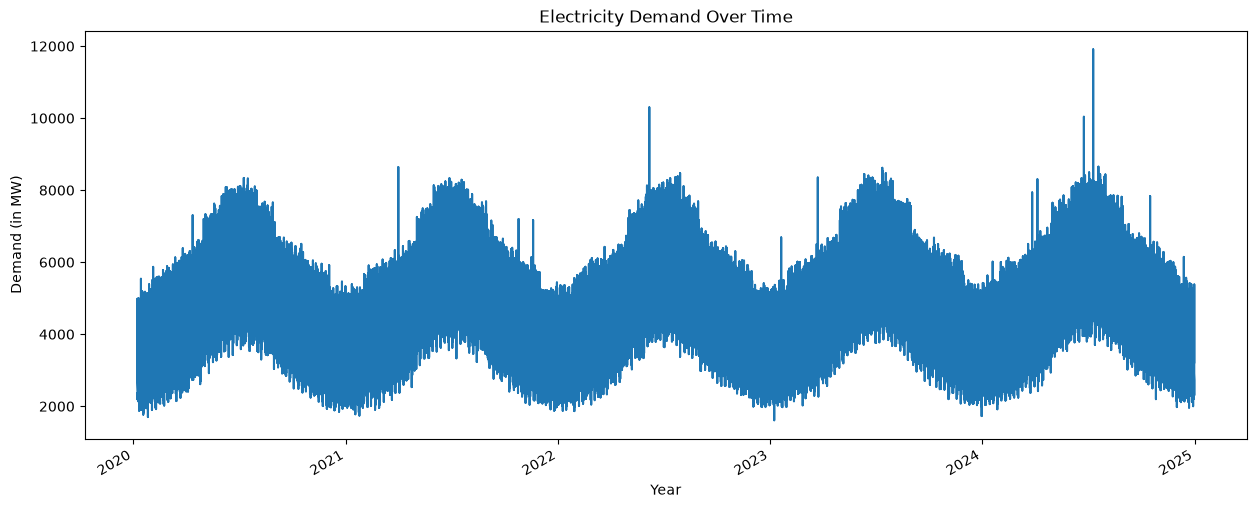

In [10]:
df['Demand'].plot(figsize =(15,6), title = "Electricity Demand Over Time")
plt.xlabel("Year")                          # naming for x-axis
plt.ylabel("Demand (in MW)")                # naming for y-axis

plt.show()

In [11]:
import seaborn as sns

Text(0.5, 1.0, 'Demand by Hour of the day')

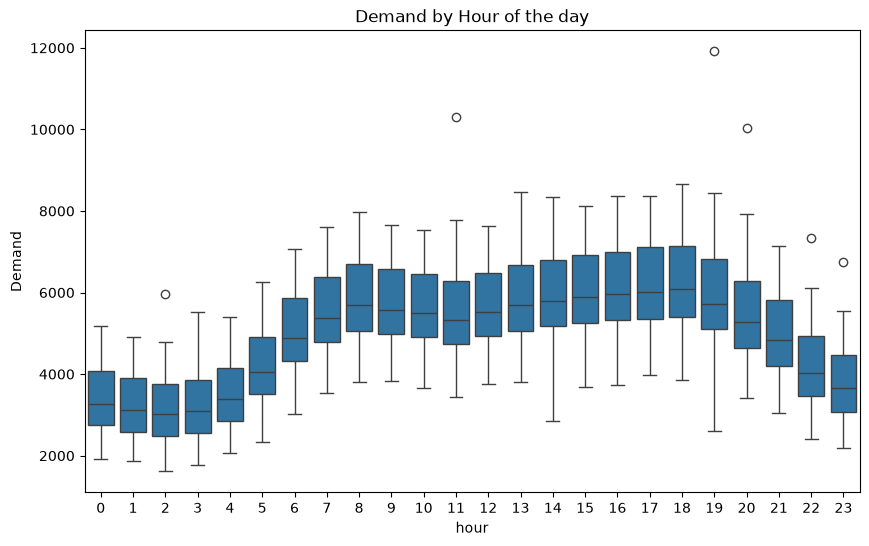

In [12]:
plt.figure(figsize = (10,6))
sns.boxplot(data = df, x = 'hour', y = 'Demand')
plt.title("Demand by Hour of the day")

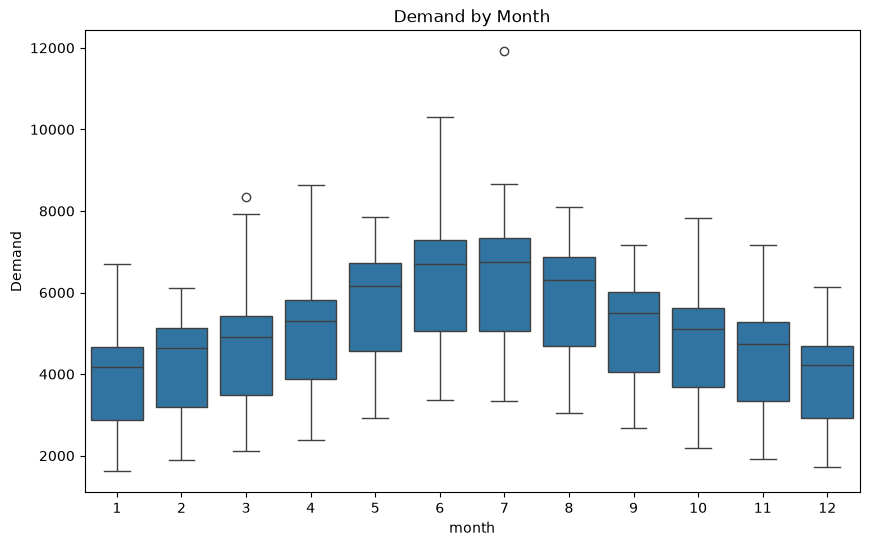

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x = 'month', y = 'Demand')
plt.title("Demand by Month")
plt.show()

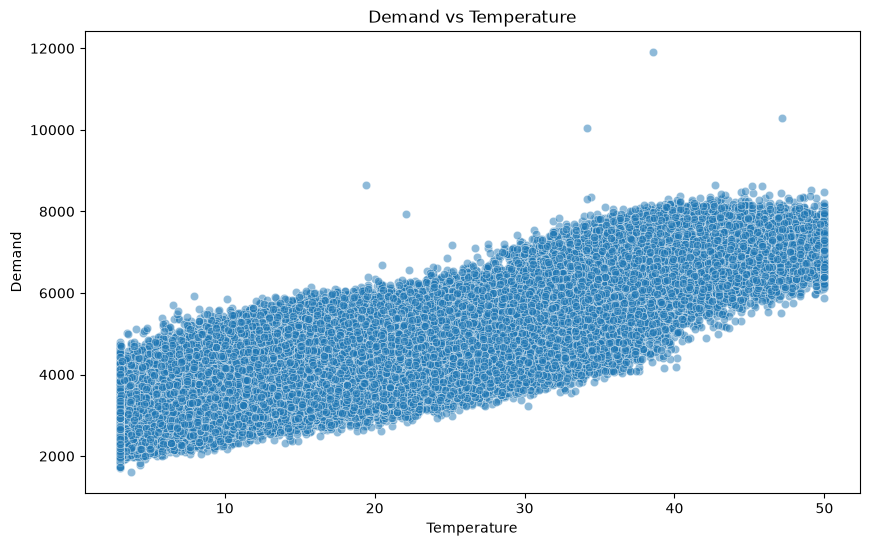

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data = df, x = 'Temperature', y = 'Demand', alpha = 0.5)  #alpha - to adjust the tranparency of points
plt.title("Demand vs Temperature")
plt.show()

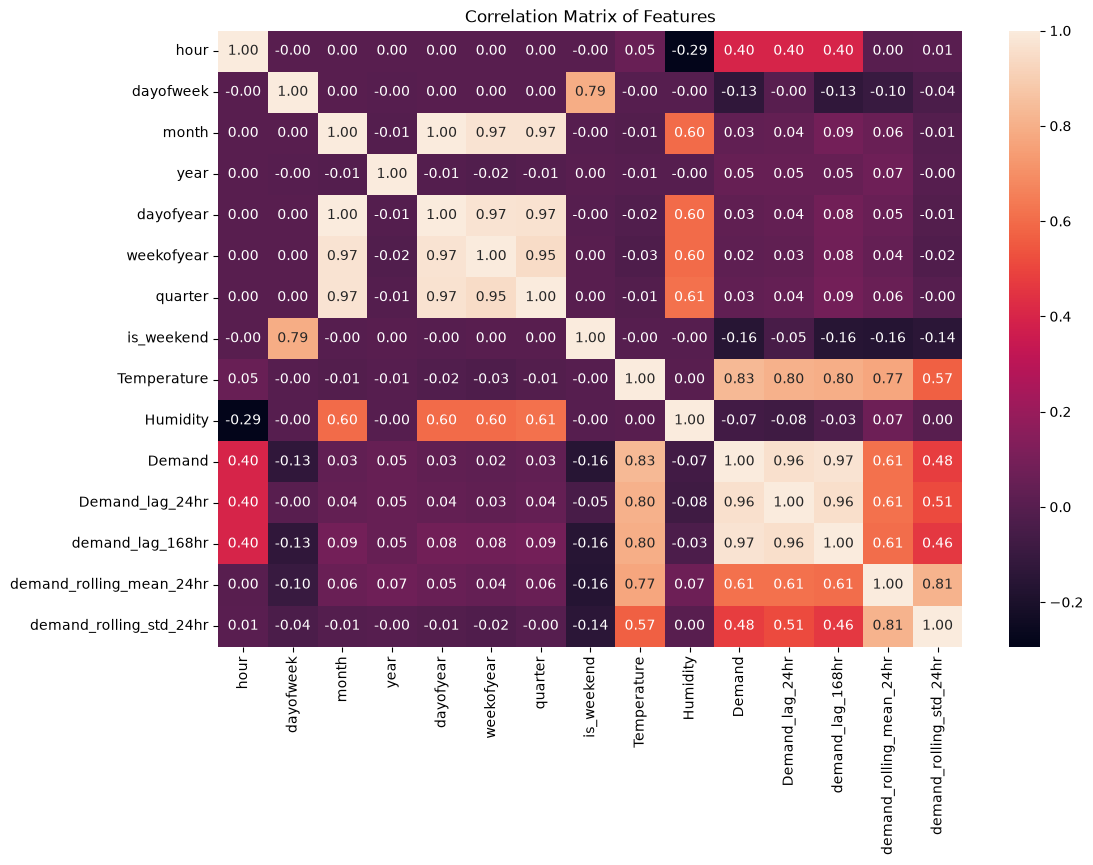

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot = True, fmt=".2f") # anoot=True : to show the numbers , fmt : to adjust decimals
plt.title("Correlation Matrix of Features")
plt.show()

In [16]:
Y = df.Demand
X = df.drop('Demand', axis=1)
X_train = X.loc[ : '2023-12-31']
Y_train = Y.loc[ : '2023-12-31' ]
X_test = X.loc[ '2024-01-01' : ]
Y_test = Y.loc[ '2024-01-01' : ]
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(34892, 14)
(34892,)
(8784, 14)
(8784,)


In [17]:
from xgboost import XGBRegressor     # from XGBoost library we are importing XGBRegressor class

# from sklearn library importing two fundamental metrics to evaluate the performance of the model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# from model_selection module of scikit-learn's library, import TimeSeriesSplit class
# TimeSeriesSplit class performs appropriate cross-validation when dealing with time series data
from sklearn.model_selection import TimeSeriesSplit

In [18]:
model_xgb = XGBRegressor(n_estimators = 1000,
                         early_stopping_rounds = 50,
                         learning_rate = 0.01,
                         random_state = 42,
                         objective = 'reg:squarederror' )

In [19]:
model_xgb.fit(X_train, Y_train, eval_set = [(X_train, Y_train), (X_test, Y_test)], verbose = False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
predictions_xgb = model_xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictions_xgb))
mae_xgb = mean_absolute_error(Y_test, predictions_xgb )
print('XGBoost RMSE:',  rmse_xgb)
print('XGBoost MAE:' ,  mae_xgb)

XGBoost RMSE: 174.7878031307984
XGBoost MAE: 123.3191299446721


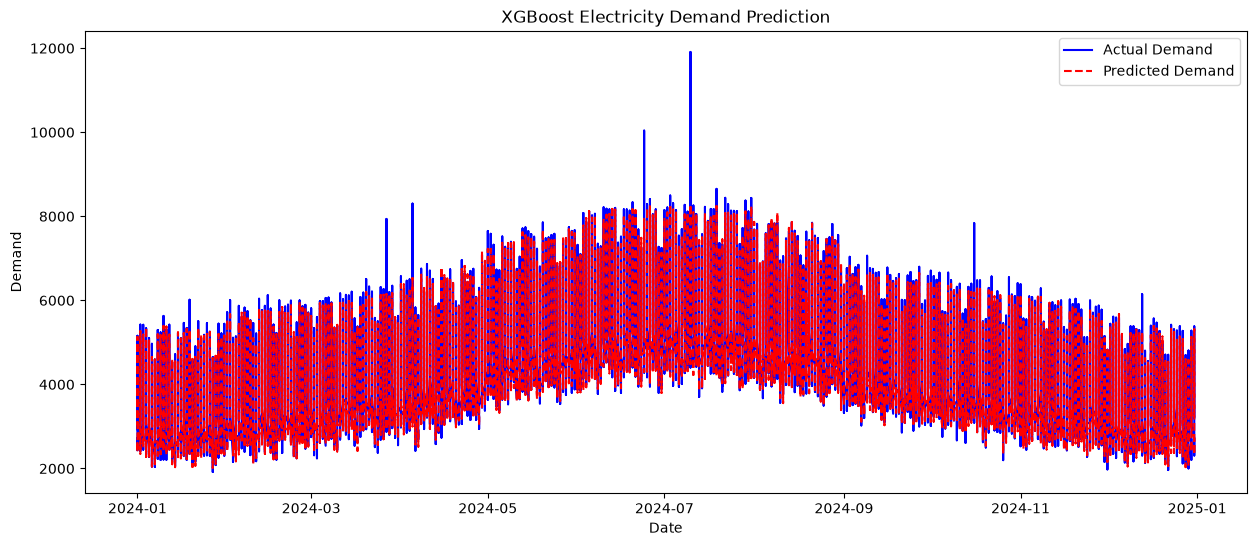

In [21]:
plt.figure(figsize = (15,6))
plt.plot(Y_test.index, Y_test, label = 'Actual Demand', color = 'Blue')
plt.plot(Y_test.index, predictions_xgb, label = 'Predicted Demand', color = 'Red', linestyle='--')
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()

plt.show()

In [22]:
from sklearn.metrics import r2_score

# R² score
r2 = r2_score(Y_test, predictions_xgb)

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((Y_test - predictions_xgb) / Y_test)) * 100

print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

R² Score: 0.9847
MAPE: 2.58%


In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [24]:
# Use the same X and Y as before (they are already split)
# But we need to scale them
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit scalers on training data only
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_y.fit_transform(Y_train.values.reshape(-1, 1))
Y_test_scaled = scaler_y.transform(Y_test.values.reshape(-1, 1))

# Create sequences
def create_sequences(X, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

window = 24  # 24 hours lookback

X_train_seq, y_train_seq = create_sequences(X_train_scaled, Y_train_scaled, window)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, Y_test_scaled, window)

print("Train sequences shape:", X_train_seq.shape)
print("Test sequences shape:", X_test_seq.shape)

Train sequences shape: (34868, 24, 14)
Test sequences shape: (8760, 24, 14)


In [25]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

e:\bracu\CSE\CSE427\project\cse427-project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0071 - val_loss: 0.0016
Epoch 2/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 3/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0019 - val_loss: 8.9065e-04
Epoch 4/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0015 - val_loss: 9.6899e-04
Epoch 5/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 6/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0012 - val_loss: 7.4408e-04
Epoch 7/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0011 - val_loss: 7.1341e-04
Epoch 8/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0010 - val_loss: 8.3851e-04
Epoch 9/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 9.9094e-04 - val_loss: 8.5163e-04
Epoch 10/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 9.8593e-04 - val_loss: 7.5158e-04
Epoch 11/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9.4172e-04 - val_los

In [26]:
# Predict on test set
y_pred_scaled = model.predict(X_test_seq)

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)  # actual test values (aligned)

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)
mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("LSTM Results:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Results:
RMSE: 217.55
MAE:  162.42
R²:   0.9763
MAPE: 3.43%


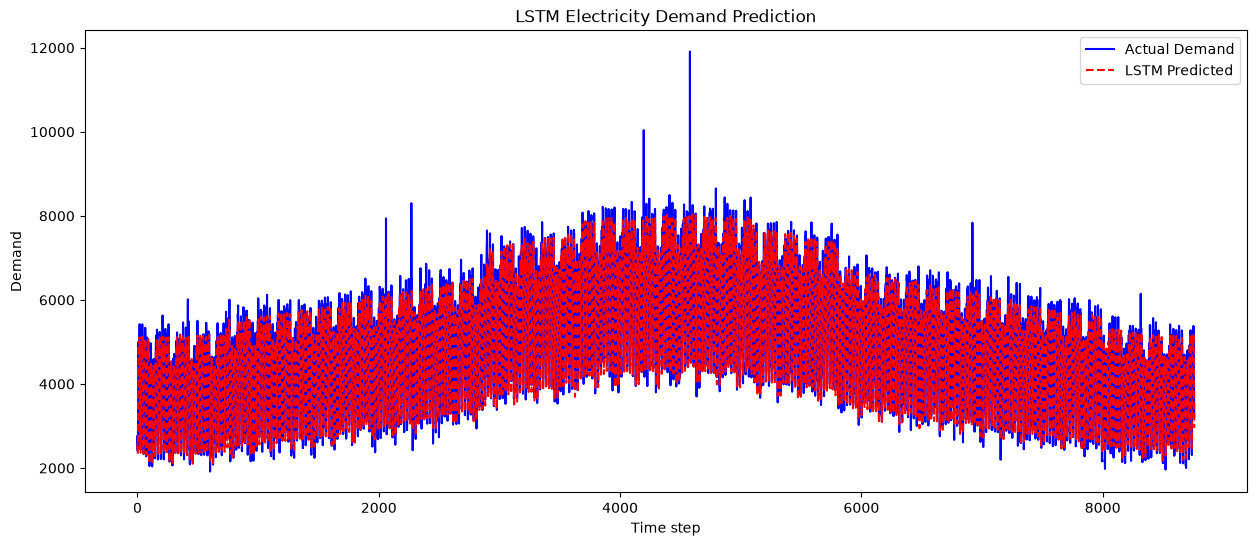

In [27]:
plt.figure(figsize=(15,6))
plt.plot(y_test_actual, label='Actual Demand', color='blue')
plt.plot(y_pred, label='LSTM Predicted', color='red', linestyle='--')
plt.title('LSTM Electricity Demand Prediction')
plt.xlabel('Time step')
plt.ylabel('Demand')
plt.legend()
plt.show()

Neural Network RMSE: 159.87
Neural Network MAE: 108.06
Neural Network R²: 0.9872
Neural Network MAPE: 2.33%


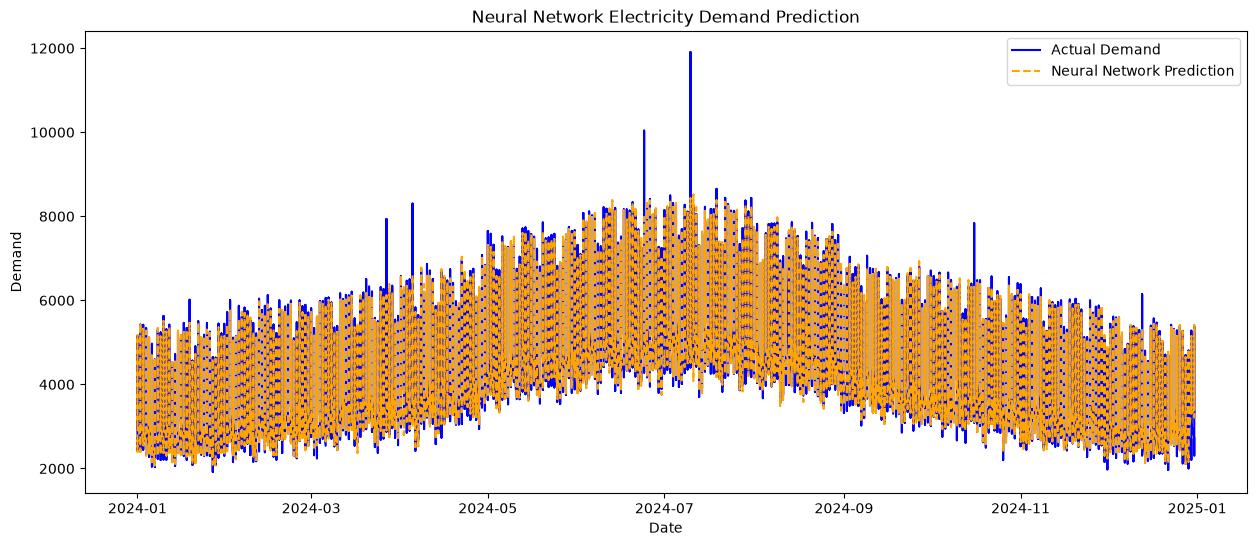

In [28]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Scale features for neural network training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Neural network regressor
nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

nn_model.fit(X_train_scaled, Y_train)

# Predict and evaluate
y_pred_nn = nn_model.predict(X_test_scaled)

rmse_nn = np.sqrt(mean_squared_error(Y_test, y_pred_nn))
mae_nn = mean_absolute_error(Y_test, y_pred_nn)
r2_nn = r2_score(Y_test, y_pred_nn)
mape_nn = np.mean(np.abs((Y_test - y_pred_nn) / Y_test)) * 100

print(f"Neural Network RMSE: {rmse_nn:.2f}")
print(f"Neural Network MAE: {mae_nn:.2f}")
print(f"Neural Network R²: {r2_nn:.4f}")
print(f"Neural Network MAPE: {mape_nn:.2f}%")

plt.figure(figsize=(15, 6))
plt.plot(Y_test.index, Y_test, label='Actual Demand', color='blue')
plt.plot(Y_test.index, y_pred_nn, label='Neural Network Prediction', color='orange', linestyle='--')
plt.title('Neural Network Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Use the same sequence data created in the LSTM section
# X_train_seq and X_test_seq are already scaled and windowed

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(window, X_train_seq.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=80,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

CNN Results:
RMSE: 218.39
MAE: 162.29
R²: 0.9761
MAPE: 3.47%


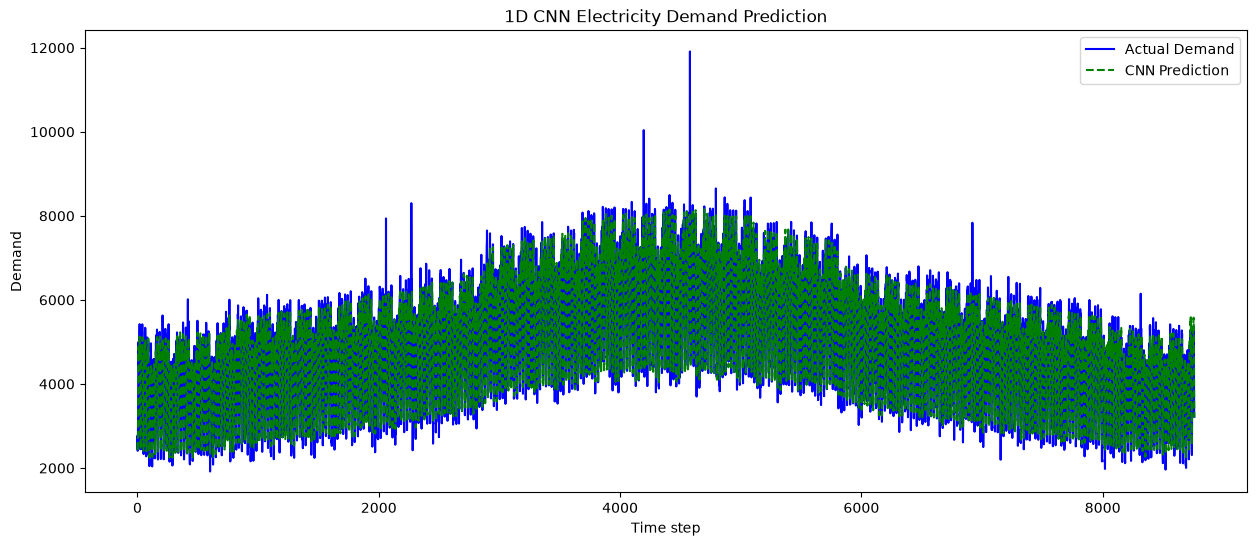


Model Comparison Summary
  Model       RMSE        MAE       R2  MAPE (%)
XGBoost 174.787803 123.319130 0.984698  2.583461
   LSTM 217.550520 162.417773 0.976296  3.431329
    CNN 218.385082 162.291322 0.976114  3.465661


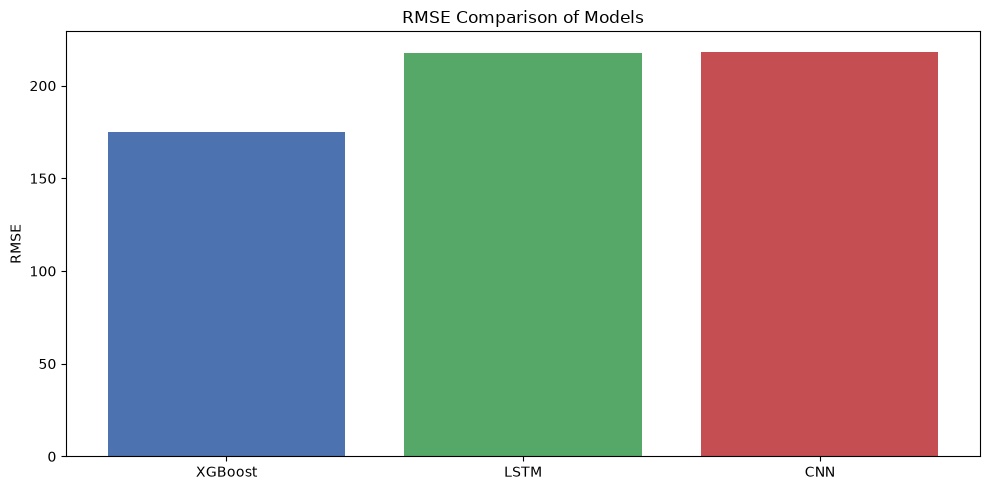

In [30]:
# Predict on test set
cnn_pred_scaled = cnn_model.predict(X_test_seq, verbose=0)
cnn_pred = scaler_y.inverse_transform(cnn_pred_scaled)
cnn_actual = scaler_y.inverse_transform(y_test_seq)

# Evaluate
rmse_cnn = np.sqrt(mean_squared_error(cnn_actual, cnn_pred))
mae_cnn = mean_absolute_error(cnn_actual, cnn_pred)
r2_cnn = r2_score(cnn_actual, cnn_pred)
mape_cnn = np.mean(np.abs((cnn_actual - cnn_pred) / cnn_actual)) * 100

print('CNN Results:')
print(f'RMSE: {rmse_cnn:.2f}')
print(f'MAE: {mae_cnn:.2f}')
print(f'R²: {r2_cnn:.4f}')
print(f'MAPE: {mape_cnn:.2f}%')

plt.figure(figsize=(15, 6))
plt.plot(cnn_actual, label='Actual Demand', color='blue')
plt.plot(cnn_pred, label='CNN Prediction', color='green', linestyle='--')
plt.title('1D CNN Electricity Demand Prediction')
plt.xlabel('Time step')
plt.ylabel('Demand')
plt.legend()
plt.show()

# Final comparison summary table for XGBoost, LSTM, and CNN
results = {
    'Model': ['XGBoost', 'LSTM', 'CNN'],
    'RMSE': [
        float(np.sqrt(mean_squared_error(Y_test, predictions_xgb))),
        float(np.sqrt(mean_squared_error(y_test_actual, y_pred))),
        float(np.sqrt(mean_squared_error(cnn_actual, cnn_pred)))
    ],
    'MAE': [
        float(mean_absolute_error(Y_test, predictions_xgb)),
        float(mean_absolute_error(y_test_actual, y_pred)),
        float(mean_absolute_error(cnn_actual, cnn_pred))
    ],
    'R2': [
        float(r2_score(Y_test, predictions_xgb)),
        float(r2_score(y_test_actual, y_pred)),
        float(r2_score(cnn_actual, cnn_pred))
    ],
    'MAPE (%)': [
        float(np.mean(np.abs((Y_test - predictions_xgb) / Y_test)) * 100),
        float(np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100),
        float(np.mean(np.abs((cnn_actual - cnn_pred) / cnn_actual)) * 100)
    ]
}

comparison_df = pd.DataFrame(results)
print('\nModel Comparison Summary')
print(comparison_df.sort_values('RMSE').reset_index(drop=True).to_string(index=False))

# Optional: bar chart for RMSE comparison
plt.figure(figsize=(10, 5))
plt.bar(comparison_df['Model'], comparison_df['RMSE'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('RMSE Comparison of Models')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
